In [2]:
# ---------------------------------------------------------
# STAGE 11A: RANDOM FOREST FOR REPURCHASE INTENT
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

loyalty_rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            loyalty_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

loyalty_rf_model.fit(
    X_train_loyalty,
    y_train_loyalty
)

print("✓ Loyalty Random Forest trained successfully.")

NameError: name 'loyalty_preprocessor' is not defined

In [3]:
# ---------------------------------------------------------
# FIX: RECREATE LOYALTY PREPROCESSOR
# ---------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify feature types
numeric_loyalty_features = X_train_loyalty.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_loyalty_features = X_train_loyalty.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_loyalty_features)

print("\nCategorical features:")
print(categorical_loyalty_features)

# Create preprocessor
loyalty_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_loyalty_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_loyalty_features
        )
    ]
)

print("\n✓ loyalty_preprocessor created successfully.")

NameError: name 'X_train_loyalty' is not defined

In [4]:
# ---------------------------------------------------------
# LOYALTY MODEL - RESET NOTEBOOK STATE
# ---------------------------------------------------------

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset path
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cleaned_survey.csv"
)

# Load data
df = pd.read_csv(DATA_PATH)

print("Dataset loaded:", df.shape)

# ---------------------------------------------------------
# TARGET
# ---------------------------------------------------------

loyalty_target = "repurchase_intent_score"

# ---------------------------------------------------------
# FEATURES
# ---------------------------------------------------------

loyalty_features = [
    "age_group",
    "gender",
    "education_level",
    "residence_type",
    "employment_status",
    "previous_purchase",
    "life_improvement_rating",
    "service_rating",
    "content_rating",
    "price_rating",
    "delivery_rating",
    "previous_experience_rating",
    "brand_solution_rating",
    "customer_support_rating",
    "overall_magazine_rating",
    "overall_experience_rating",
    "recommendation"
]

# Create modeling dataset
loyalty_df = df[
    loyalty_features + [loyalty_target]
].copy()

# Remove rows with missing values just in case
loyalty_df = loyalty_df.dropna()

print("Modeling dataset:", loyalty_df.shape)

# ---------------------------------------------------------
# X AND y
# ---------------------------------------------------------

X_loyalty = loyalty_df[loyalty_features].copy()
y_loyalty = loyalty_df[loyalty_target].copy()

# ---------------------------------------------------------
# TRAIN / TEST SPLIT
# ---------------------------------------------------------

X_train_loyalty, X_test_loyalty, y_train_loyalty, y_test_loyalty = (
    train_test_split(
        X_loyalty,
        y_loyalty,
        test_size=0.20,
        random_state=42,
        stratify=y_loyalty
    )
)

print("\nTraining rows:", len(X_train_loyalty))
print("Testing rows :", len(X_test_loyalty))

# ---------------------------------------------------------
# IDENTIFY FEATURE TYPES
# ---------------------------------------------------------

numeric_loyalty_features = (
    X_train_loyalty
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

categorical_loyalty_features = (
    X_train_loyalty
    .select_dtypes(
        include=["object", "category", "bool"]
    )
    .columns
    .tolist()
)

print("\nNumeric features:")
print(numeric_loyalty_features)

print("\nCategorical features:")
print(categorical_loyalty_features)

# ---------------------------------------------------------
# CREATE PREPROCESSOR
# ---------------------------------------------------------

loyalty_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_loyalty_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_loyalty_features
        )
    ]
)

print("\n✓ Loyalty modeling environment is ready.")

Dataset loaded: (11109, 101)
Modeling dataset: (11109, 18)

Training rows: 8887
Testing rows : 2222

Numeric features:
['life_improvement_rating', 'service_rating', 'content_rating', 'price_rating', 'delivery_rating', 'previous_experience_rating', 'brand_solution_rating', 'customer_support_rating', 'overall_magazine_rating', 'overall_experience_rating', 'recommendation']

Categorical features:
['age_group', 'gender', 'education_level', 'residence_type', 'employment_status', 'previous_purchase']

✓ Loyalty modeling environment is ready.


C:\Users\DIVYANSHU KASHYAP\AppData\Local\Temp\ipykernel_15740\2414894446.py:106: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

loyalty_rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            loyalty_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

loyalty_rf_model.fit(
    X_train_loyalty,
    y_train_loyalty
)

print("✓ Loyalty Random Forest trained successfully.")

✓ Loyalty Random Forest trained successfully.


In [6]:
# ---------------------------------------------------------
# STAGE 11B: LOYALTY RANDOM FOREST EVALUATION
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    confusion_matrix,
    classification_report
)

# Predictions
rf_loyalty_pred = loyalty_rf_model.predict(
    X_test_loyalty
)

# Metrics
rf_loyalty_accuracy = accuracy_score(
    y_test_loyalty,
    rf_loyalty_pred
)

rf_loyalty_mae = mean_absolute_error(
    y_test_loyalty,
    rf_loyalty_pred
)

rf_loyalty_within_one = (
    np.abs(
        y_test_loyalty.to_numpy()
        - rf_loyalty_pred
    ) <= 1
).mean()

rf_loyalty_confusion = confusion_matrix(
    y_test_loyalty,
    rf_loyalty_pred,
    labels=[1, 2, 3]
)

print("=" * 60)
print("LOYALTY RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"Exact Accuracy       : {rf_loyalty_accuracy:.4f}")
print(f"Mean Absolute Error  : {rf_loyalty_mae:.4f}")
print(f"Within-1 Accuracy    : {rf_loyalty_within_one:.4f}")

print("\nConfusion Matrix:")
print(rf_loyalty_confusion)

print("\nClassification Report:")
print(
    classification_report(
        y_test_loyalty,
        rf_loyalty_pred,
        labels=[1, 2, 3],
        target_names=[
            "No",
            "Will think of it",
            "Yes"
        ],
        zero_division=0
    )
)


LOYALTY RANDOM FOREST PERFORMANCE
Exact Accuracy       : 0.3231
Mean Absolute Error  : 0.9464
Within-1 Accuracy    : 0.7304

Confusion Matrix:
[[211 188 335]
 [209 200 324]
 [264 184 307]]

Classification Report:
                  precision    recall  f1-score   support

              No       0.31      0.29      0.30       734
Will think of it       0.35      0.27      0.31       733
             Yes       0.32      0.41      0.36       755

        accuracy                           0.32      2222
       macro avg       0.33      0.32      0.32      2222
    weighted avg       0.33      0.32      0.32      2222



In [7]:
# ---------------------------------------------------------
# STAGE 11C: FINAL LOYALTY MODEL COMPARISON
# ---------------------------------------------------------

loyalty_full_comparison = pd.DataFrame({
    "model": [
        "Majority Class Baseline",
        "Ordinal Logistic Regression",
        "Random Forest"
    ],
    "accuracy": [
        baseline_loyalty_accuracy,
        loyalty_accuracy,
        rf_loyalty_accuracy
    ],
    "mae": [
        baseline_loyalty_mae,
        loyalty_mae,
        rf_loyalty_mae
    ],
    "within_one_accuracy": [
        baseline_loyalty_within_one,
        within_one,
        rf_loyalty_within_one
    ]
})

print("=" * 60)
print("FINAL LOYALTY MODEL COMPARISON")
print("=" * 60)

display(
    loyalty_full_comparison.round(4)
)

NameError: name 'baseline_loyalty_accuracy' is not defined

In [8]:
# ---------------------------------------------------------
# STAGE 11C: FINAL LOYALTY MODEL COMPARISON
# ---------------------------------------------------------

from sklearn.metrics import accuracy_score, mean_absolute_error

# ---------------------------------------------------------
# 1. RANDOM FOREST METRICS
# ---------------------------------------------------------

rf_loyalty_accuracy = accuracy_score(
    y_test_loyalty,
    rf_loyalty_pred
)

rf_loyalty_mae = mean_absolute_error(
    y_test_loyalty,
    rf_loyalty_pred
)

rf_loyalty_within_one = (
    np.abs(
        y_test_loyalty.to_numpy()
        - rf_loyalty_pred
    ) <= 1
).mean()


# ---------------------------------------------------------
# 2. MAJORITY-CLASS BASELINE
# ---------------------------------------------------------

# Determine majority class directly from training data
majority_class = y_train_loyalty.mode()[0]

baseline_loyalty_pred = np.full(
    len(y_test_loyalty),
    majority_class
)

baseline_loyalty_accuracy = accuracy_score(
    y_test_loyalty,
    baseline_loyalty_pred
)

baseline_loyalty_mae = mean_absolute_error(
    y_test_loyalty,
    baseline_loyalty_pred
)

baseline_loyalty_within_one = (
    np.abs(
        y_test_loyalty.to_numpy()
        - baseline_loyalty_pred
    ) <= 1
).mean()


# ---------------------------------------------------------
# 3. ORDINAL LOGISTIC REGRESSION
# ---------------------------------------------------------

# Generate ordinal predictions again directly
test_probabilities = ordinal_result.model.predict(
    ordinal_result.params,
    exog=X_test_loyalty_encoded
)

class_values = np.array([1, 2, 3])

y_pred_loyalty = class_values[
    np.argmax(test_probabilities, axis=1)
]

loyalty_accuracy = accuracy_score(
    y_test_loyalty,
    y_pred_loyalty
)

loyalty_mae = mean_absolute_error(
    y_test_loyalty,
    y_pred_loyalty
)

within_one = (
    np.abs(
        y_test_loyalty.to_numpy()
        - y_pred_loyalty
    ) <= 1
).mean()


# ---------------------------------------------------------
# 4. CREATE COMPARISON TABLE
# ---------------------------------------------------------

loyalty_full_comparison = pd.DataFrame({
    "model": [
        "Majority Class Baseline",
        "Ordinal Logistic Regression",
        "Random Forest"
    ],
    "accuracy": [
        baseline_loyalty_accuracy,
        loyalty_accuracy,
        rf_loyalty_accuracy
    ],
    "mae": [
        baseline_loyalty_mae,
        loyalty_mae,
        rf_loyalty_mae
    ],
    "within_one_accuracy": [
        baseline_loyalty_within_one,
        within_one,
        rf_loyalty_within_one
    ]
})

print("=" * 60)
print("FINAL LOYALTY MODEL COMPARISON")
print("=" * 60)

display(
    loyalty_full_comparison.round(4)
)

NameError: name 'ordinal_result' is not defined

In [9]:
# ---------------------------------------------------------
# FIX: RECREATE ORDINAL LOGISTIC MODEL
# ---------------------------------------------------------

from statsmodels.miscmodels.ordinal_model import OrderedModel

# Encode the training data
X_train_loyalty_encoded = loyalty_preprocessor.fit_transform(
    X_train_loyalty
)

X_test_loyalty_encoded = loyalty_preprocessor.transform(
    X_test_loyalty
)

# Convert sparse matrices to dense
if hasattr(X_train_loyalty_encoded, "toarray"):
    X_train_loyalty_encoded = X_train_loyalty_encoded.toarray()

if hasattr(X_test_loyalty_encoded, "toarray"):
    X_test_loyalty_encoded = X_test_loyalty_encoded.toarray()

# Feature names
loyalty_feature_names = (
    loyalty_preprocessor.get_feature_names_out()
)

# Fit ordinal logistic regression
ordinal_model = OrderedModel(
    y_train_loyalty,
    X_train_loyalty_encoded,
    distr="logit"
)

ordinal_result = ordinal_model.fit(
    method="bfgs",
    disp=False,
    maxiter=1000
)

print("✓ Ordinal Logistic Regression recreated successfully.")

✓ Ordinal Logistic Regression recreated successfully.


In [10]:
# ---------------------------------------------------------
# FIX: RECREATE RANDOM FOREST PREDICTIONS
# ---------------------------------------------------------

rf_loyalty_pred = loyalty_rf_model.predict(
    X_test_loyalty
)

print("✓ Random Forest predictions created.")

✓ Random Forest predictions created.


In [11]:
# ---------------------------------------------------------
# STAGE 11C: FINAL LOYALTY MODEL COMPARISON
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error
)

# ---------------------------------------------------------
# 1. ORDINAL LOGISTIC REGRESSION
# ---------------------------------------------------------

ordinal_probabilities = ordinal_result.model.predict(
    ordinal_result.params,
    exog=X_test_loyalty_encoded
)

class_values = np.array([1, 2, 3])

ordinal_pred = class_values[
    np.argmax(ordinal_probabilities, axis=1)
]

ordinal_accuracy = accuracy_score(
    y_test_loyalty,
    ordinal_pred
)

ordinal_mae = mean_absolute_error(
    y_test_loyalty,
    ordinal_pred
)

ordinal_within_one = (
    np.abs(
        y_test_loyalty.to_numpy()
        - ordinal_pred
    ) <= 1
).mean()


# ---------------------------------------------------------
# 2. RANDOM FOREST
# ---------------------------------------------------------

rf_accuracy = accuracy_score(
    y_test_loyalty,
    rf_loyalty_pred
)

rf_mae = mean_absolute_error(
    y_test_loyalty,
    rf_loyalty_pred
)

rf_within_one = (
    np.abs(
        y_test_loyalty.to_numpy()
        - rf_loyalty_pred
    ) <= 1
).mean()


# ---------------------------------------------------------
# 3. MAJORITY-CLASS BASELINE
# ---------------------------------------------------------

majority_class = y_train_loyalty.mode()[0]

baseline_pred = np.full(
    len(y_test_loyalty),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test_loyalty,
    baseline_pred
)

baseline_mae = mean_absolute_error(
    y_test_loyalty,
    baseline_pred
)

baseline_within_one = (
    np.abs(
        y_test_loyalty.to_numpy()
        - baseline_pred
    ) <= 1
).mean()


# ---------------------------------------------------------
# 4. FINAL COMPARISON
# ---------------------------------------------------------

loyalty_full_comparison = pd.DataFrame({
    "model": [
        "Majority Class Baseline",
        "Ordinal Logistic Regression",
        "Random Forest"
    ],
    "accuracy": [
        baseline_accuracy,
        ordinal_accuracy,
        rf_accuracy
    ],
    "mae": [
        baseline_mae,
        ordinal_mae,
        rf_mae
    ],
    "within_one_accuracy": [
        baseline_within_one,
        ordinal_within_one,
        rf_within_one
    ]
})

print("=" * 60)
print("FINAL LOYALTY MODEL COMPARISON")
print("=" * 60)

display(
    loyalty_full_comparison.round(4)
)

FINAL LOYALTY MODEL COMPARISON


,model,accuracy,mae,within_one_accuracy
0,Majority Class Baseline,0.3398,0.9905,0.6697
1,Ordinal Logistic Regression,0.3294,1.0113,0.6593
2,Random Forest,0.3231,0.9464,0.7304


In [12]:
# ---------------------------------------------------------
# STAGE 11D: LOYALTY RANDOM FOREST CROSS-VALIDATION
# ---------------------------------------------------------

from sklearn.model_selection import StratifiedKFold, cross_validate

loyalty_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

loyalty_rf_cv = cross_validate(
    loyalty_rf_model,
    X_loyalty,
    y_loyalty,
    cv=loyalty_cv,
    scoring=[
        "accuracy",
        "f1_weighted"
    ],
    n_jobs=-1
)

loyalty_rf_cv_summary = pd.DataFrame({
    "metric": [
        "accuracy",
        "f1_weighted"
    ],
    "mean": [
        loyalty_rf_cv["test_accuracy"].mean(),
        loyalty_rf_cv["test_f1_weighted"].mean()
    ],
    "std": [
        loyalty_rf_cv["test_accuracy"].std(),
        loyalty_rf_cv["test_f1_weighted"].std()
    ]
})

print("=" * 60)
print("LOYALTY RANDOM FOREST - 5-FOLD CV")
print("=" * 60)

display(
    loyalty_rf_cv_summary.round(4)
)

LOYALTY RANDOM FOREST - 5-FOLD CV


,metric,mean,std
0,accuracy,0.3327,0.0073
1,f1_weighted,0.3282,0.0075


In [13]:
# ---------------------------------------------------------
# STAGE 11E: SAVE LOYALTY MODEL COMPARISON
# ---------------------------------------------------------

final_loyalty_comparison_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "loyalty_model_comparison.csv"
)

loyalty_full_comparison.to_csv(
    final_loyalty_comparison_path,
    index=False
)

loyalty_rf_cv_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "loyalty_random_forest_cv.csv"
)

loyalty_rf_cv_summary.to_csv(
    loyalty_rf_cv_path,
    index=False
)

print("✓ Final loyalty comparison saved:")
print(final_loyalty_comparison_path)

print("\n✓ Random Forest CV results saved:")
print(loyalty_rf_cv_path)

✓ Final loyalty comparison saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\loyalty_model_comparison.csv

✓ Random Forest CV results saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\loyalty_random_forest_cv.csv


In [14]:
# ---------------------------------------------------------
# STAGE 11F: LOYALTY RANDOM FOREST FEATURE IMPORTANCE
# ---------------------------------------------------------

# Get the fitted preprocessing step
loyalty_rf_preprocessor = (
    loyalty_rf_model.named_steps["preprocessor"]
)

# Get the fitted Random Forest
loyalty_rf_classifier = (
    loyalty_rf_model.named_steps["classifier"]
)

# Get transformed feature names
loyalty_rf_feature_names = (
    loyalty_rf_preprocessor
    .get_feature_names_out()
)

# Get feature importance
loyalty_rf_importance = (
    loyalty_rf_classifier.feature_importances_
)

# Create importance table
loyalty_rf_importance_table = pd.DataFrame({
    "feature": loyalty_rf_feature_names,
    "importance": loyalty_rf_importance
})

# Sort
loyalty_rf_importance_table = (
    loyalty_rf_importance_table
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("LOYALTY RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

display(
    loyalty_rf_importance_table
    .head(20)
    .round(4)
)

LOYALTY RANDOM FOREST FEATURE IMPORTANCE


,feature,importance
0,numeric__customer_support_rating,0.0664
1,numeric__service_rating,0.0662
2,numeric__previous_experience_rating,0.0660
3,numeric__delivery_rating,0.0647
4,numeric__overall_experience_rating,0.0646
5,numeric__recommendation,0.0642
6,numeric__brand_solution_rating,0.0641
7,numeric__life_improvement_rating,0.0640
8,numeric__content_rating,0.0638
9,numeric__overall_magazine_rating,0.0636


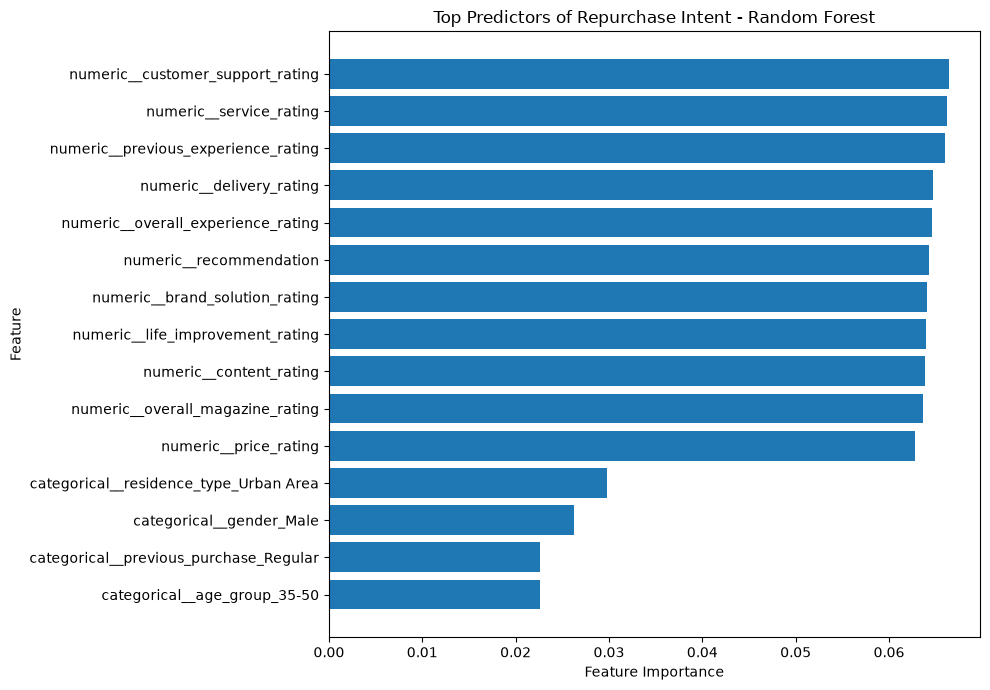

In [16]:
# ---------------------------------------------------------
# STAGE 11G: LOYALTY FEATURE IMPORTANCE VISUALIZATION
# ---------------------------------------------------------

import matplotlib.pyplot as plt

top_loyalty_features = (
    loyalty_rf_importance_table
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_loyalty_features["feature"],
    top_loyalty_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top Predictors of Repurchase Intent - Random Forest"
)

plt.tight_layout()
plt.show()

In [17]:
# ---------------------------------------------------------
# STAGE 11H: LOYALTY PERMUTATION IMPORTANCE
# ---------------------------------------------------------

from sklearn.inspection import permutation_importance

loyalty_permutation_result = permutation_importance(
    loyalty_rf_model,
    X_test_loyalty,
    y_test_loyalty,
    scoring="accuracy",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

loyalty_permutation_table = pd.DataFrame({
    "feature": X_test_loyalty.columns,
    "importance_mean": (
        loyalty_permutation_result.importances_mean
    ),
    "importance_std": (
        loyalty_permutation_result.importances_std
    )
})

loyalty_permutation_table = (
    loyalty_permutation_table
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("LOYALTY PERMUTATION IMPORTANCE")
print("=" * 60)

display(
    loyalty_permutation_table.round(4)
)

LOYALTY PERMUTATION IMPORTANCE


,feature,importance_mean,importance_std
0,recommendation,0.0049,0.0034
1,previous_purchase,0.0037,0.0035
2,overall_experience_rating,-0.0005,0.0047
3,customer_support_rating,-0.0016,0.0032
4,content_rating,-0.0042,0.0052
5,residence_type,-0.0046,0.0021
6,price_rating,-0.0055,0.0038
7,overall_magazine_rating,-0.0062,0.0049
8,gender,-0.0071,0.0030
9,previous_experience_rating,-0.0072,0.0070


In [18]:
# ---------------------------------------------------------
# STAGE 11I: SAVE LOYALTY IMPORTANCE RESULTS
# ---------------------------------------------------------

rf_importance_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "loyalty_random_forest_importance.csv"
)

loyalty_rf_importance_table.to_csv(
    rf_importance_path,
    index=False
)

permutation_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "loyalty_permutation_importance.csv"
)

loyalty_permutation_table.to_csv(
    permutation_path,
    index=False
)

print("✓ Random Forest importance saved:")
print(rf_importance_path)

print("\n✓ Permutation importance saved:")
print(permutation_path)

✓ Random Forest importance saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\loyalty_random_forest_importance.csv

✓ Permutation importance saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\loyalty_permutation_importance.csv


Confusion Matrix:


,Predicted: No,Predicted: Will think,Predicted: Yes
Actual: No,211,188,335
Actual: Will think,209,200,324
Actual: Yes,264,184,307


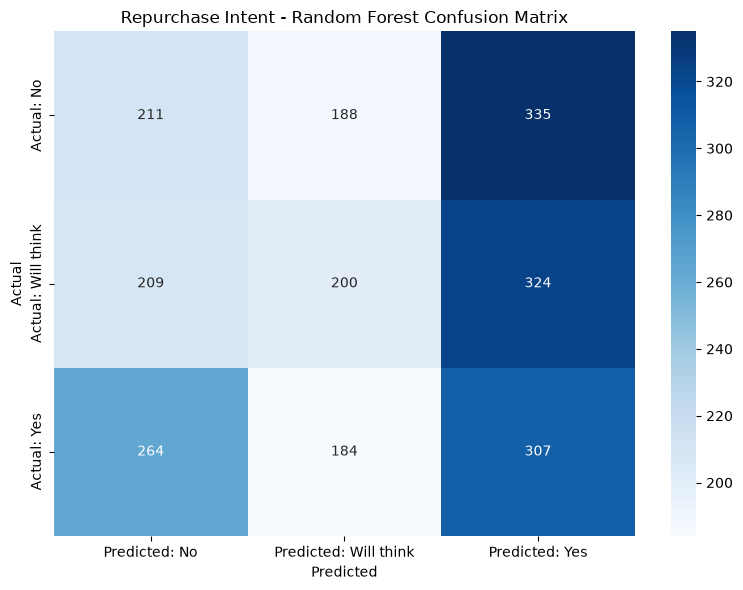

In [19]:
# ---------------------------------------------------------
# STAGE 12A: LOYALTY CONFUSION MATRIX
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create confusion matrix
loyalty_cm = confusion_matrix(
    y_test_loyalty,
    rf_loyalty_pred,
    labels=[1, 2, 3]
)

# Convert to DataFrame for readability
loyalty_cm_df = pd.DataFrame(
    loyalty_cm,
    index=[
        "Actual: No",
        "Actual: Will think",
        "Actual: Yes"
    ],
    columns=[
        "Predicted: No",
        "Predicted: Will think",
        "Predicted: Yes"
    ]
)

print("Confusion Matrix:")
display(loyalty_cm_df)

# Plot
plt.figure(figsize=(8, 6))

sns.heatmap(
    loyalty_cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Repurchase Intent - Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [20]:
# ---------------------------------------------------------
# STAGE 12B: ORDINAL PREDICTION ERROR
# ---------------------------------------------------------

error_analysis = pd.DataFrame({
    "actual": y_test_loyalty.to_numpy(),
    "predicted": rf_loyalty_pred
})

error_analysis["error"] = (
    error_analysis["predicted"]
    - error_analysis["actual"]
)

error_analysis["absolute_error"] = (
    error_analysis["error"].abs()
)

print("=" * 60)
print("ORDINAL PREDICTION ERROR")
print("=" * 60)

print("\nError distribution:")
display(
    error_analysis["error"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

print("\nMean absolute error:")
print(
    error_analysis["absolute_error"].mean().round(4)
)

print("\nSevere errors (2 categories away):")
print(
    (error_analysis["absolute_error"] == 2).sum()
)

ORDINAL PREDICTION ERROR

Error distribution:


,count
error,
-2,264
-1,393
0,718
1,512
2,335



Mean absolute error:
0.9464

Severe errors (2 categories away):
599


In [21]:
# ---------------------------------------------------------
# STAGE 12C: SAVE LOYALTY ERROR ANALYSIS
# ---------------------------------------------------------

error_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "loyalty_prediction_errors.csv"
)

error_analysis.to_csv(
    error_path,
    index=False
)

confusion_path = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "loyalty_confusion_matrix.csv"
)

loyalty_cm_df.to_csv(
    confusion_path
)

print("✓ Prediction errors saved:")
print(error_path)

print("\n✓ Confusion matrix saved:")
print(confusion_path)

✓ Prediction errors saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\loyalty_prediction_errors.csv

✓ Confusion matrix saved:
c:\Users\DIVYANSHU KASHYAP\Desktop\OUTLOOK-CUSTOMER-INTELLIGENCE\outputs\tables\loyalty_confusion_matrix.csv
